In [26]:
import os
import pandas as pd
import numpy as np
import boto3

In [27]:
print(os.getcwd())

/home/sagemaker-user/ADS508_material_work/ADS508_final_project


In [28]:
nflix_training = pd.read_csv("training/nflix_training.csv")

print("Shape:", nflix_training.shape)
nflix_training.head()

Shape: (400000, 6)


,user_id,movie_id,rating,year,title,release_year
0,1488844,1,3,2005,Dinosaur Planet,2003
1,822109,1,5,2005,Dinosaur Planet,2003
2,885013,1,4,2005,Dinosaur Planet,2003
3,30878,1,4,2005,Dinosaur Planet,2003
4,823519,1,3,2004,Dinosaur Planet,2003


In [29]:
bucket = "amzn-s3-netflixbucket-ads508"  
local_file = "training/nflix_training.csv"
s3_key = "training/nflix_training.csv"

s3 = boto3.client("s3")
s3.upload_file(local_file, bucket, s3_key)

print(f"Uploaded to s3://{bucket}/{s3_key}")

Uploaded to s3://amzn-s3-netflixbucket-ads508/training/nflix_training.csv


In [30]:
athena_results = "s3://amzn-s3-netflixbucket-ads508/athena-results/"
print(athena_results)

s3://amzn-s3-netflixbucket-ads508/athena-results/


In [31]:
import time

region = "us-east-1"   # change only if your bucket/Athena work in another region
database_name = "netflix_project_db"
athena_results = "s3://amzn-s3-netflixbucket-ads508/athena-results/"

athena = boto3.client("athena", region_name=region)

def run_query(query, database="default"):
    response = athena.start_query_execution(
        QueryString=query,
        QueryExecutionContext={"Database": database},
        ResultConfiguration={"OutputLocation": athena_results}
    )
    query_id = response["QueryExecutionId"]

    while True:
        result = athena.get_query_execution(QueryExecutionId=query_id)
        state = result["QueryExecution"]["Status"]["State"]
        if state in ["SUCCEEDED", "FAILED", "CANCELLED"]:
            print("Status:", state)
            if state != "SUCCEEDED":
                print(result["QueryExecution"]["Status"].get("StateChangeReason", "No error message"))
            break
        time.sleep(2)

    return query_id

create_db = """
CREATE DATABASE IF NOT EXISTS netflix_project_db
"""

run_query(create_db)

Status: SUCCEEDED


'6a5c8fb9-b9e7-4cd7-827d-c39aa4e62dcd'

In [32]:
create_table = """
CREATE EXTERNAL TABLE IF NOT EXISTS netflix_project_db.nflix_training (
    user_id BIGINT,
    movie_id BIGINT,
    rating INT,
    year INT,
    title STRING,
    release_year INT
)
ROW FORMAT SERDE 'org.apache.hadoop.hive.serde2.OpenCSVSerde'
WITH SERDEPROPERTIES (
    'separatorChar' = ',',
    'quoteChar' = '\"',
    'escapeChar' = '\\\\'
)
STORED AS TEXTFILE
LOCATION 's3://amzn-s3-netflixbucket-ads508/training/'
TBLPROPERTIES ('skip.header.line.count'='1')
"""

run_query(create_table, database="netflix_project_db")

Status: SUCCEEDED


'ee950623-6bb3-4088-95f3-9e4b5d8238fe'

In [33]:
def get_query_results(query_id):
    results = athena.get_query_results(QueryExecutionId=query_id)
    rows = results["ResultSet"]["Rows"]
    data = [[col.get("VarCharValue", "") for col in row["Data"]] for row in rows]
    return pd.DataFrame(data[1:], columns=data[0])

In [34]:
query_total_rows = """
SELECT COUNT(*) AS total_rows
FROM nflix_training
"""

qid = run_query(query_total_rows, database="netflix_project_db")
get_query_results(qid)

Status: SUCCEEDED


,total_rows
0,400000


In [35]:
query_rating_dist = """
SELECT rating, COUNT(*) AS rating_count
FROM nflix_training
GROUP BY rating
ORDER BY rating
"""

qid = run_query(query_rating_dist, database="netflix_project_db")
get_query_results(qid)

Status: SUCCEEDED


,rating,rating_count
0,1,19745
1,2,41620
2,3,121019
3,4,134306
4,5,83310


In [36]:
query_top_movies = """
SELECT title, COUNT(*) AS num_ratings
FROM nflix_training
GROUP BY title
ORDER BY num_ratings DESC
LIMIT 10
"""

qid = run_query(query_top_movies, database="netflix_project_db")
get_query_results(qid)

Status: SUCCEEDED


,title,num_ratings
0,Lilo and Stitch,39752
1,Kramer vs. Kramer,37884
2,Breakfast at Tiffany's,33731
3,Grumpier Old Men,26500
4,G.I. Jane,20214
5,His Girl Friday,16553
6,Mighty Joe Young,15704
7,What the #$*! Do We Know!?,14910
8,Boat Trip,14685
9,Immortal Beloved,10722


In [37]:
query_avg_by_release = """
SELECT release_year, AVG(rating) AS avg_rating
FROM nflix_training
WHERE release_year IS NOT NULL
GROUP BY release_year
ORDER BY release_year
"""

qid = run_query(query_avg_by_release, database="netflix_project_db")
get_query_results(qid)

Status: SUCCEEDED


,release_year,avg_rating
0,1933,3.7318501170960188
1,1940,3.898386999335468
2,1945,3.3294573643410854
3,1947,3.4175824175824174
4,1949,3.954954954954955
5,1959,2.907563025210084
6,1960,3.627709978463747
7,1961,3.923897898075954
8,1962,3.5274725274725274
9,1963,3.8648526077097505


In [38]:
print(nflix_training["year"].value_counts().sort_index())

year
1999         2
2000      3414
2001      8152
2002     17583
2003     48620
2004    126598
2005    195631
Name: count, dtype: int64


In [39]:
from sklearn.model_selection import train_test_split

In [40]:
nflix_training = nflix_training.sort_values("year").reset_index(drop=True)

train_end = int(len(nflix_training) * 0.8)
val_end = int(len(nflix_training) * 0.9)

train_df = nflix_training.iloc[:train_end]
val_df = nflix_training.iloc[train_end:val_end]
test_df = nflix_training.iloc[val_end:]

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

Train shape: (320000, 6)
Validation shape: (40000, 6)
Test shape: (40000, 6)


In [41]:
print("Train years:")
print(train_df["year"].value_counts().sort_index())

print("\nValidation years:")
print(val_df["year"].value_counts().sort_index())

print("\nTest years:")
print(test_df["year"].value_counts().sort_index())

Train years:
year
1999         2
2000      3414
2001      8152
2002     17583
2003     48620
2004    126598
2005    115631
Name: count, dtype: int64

Validation years:
year
2005    40000
Name: count, dtype: int64

Test years:
year
2005    40000
Name: count, dtype: int64


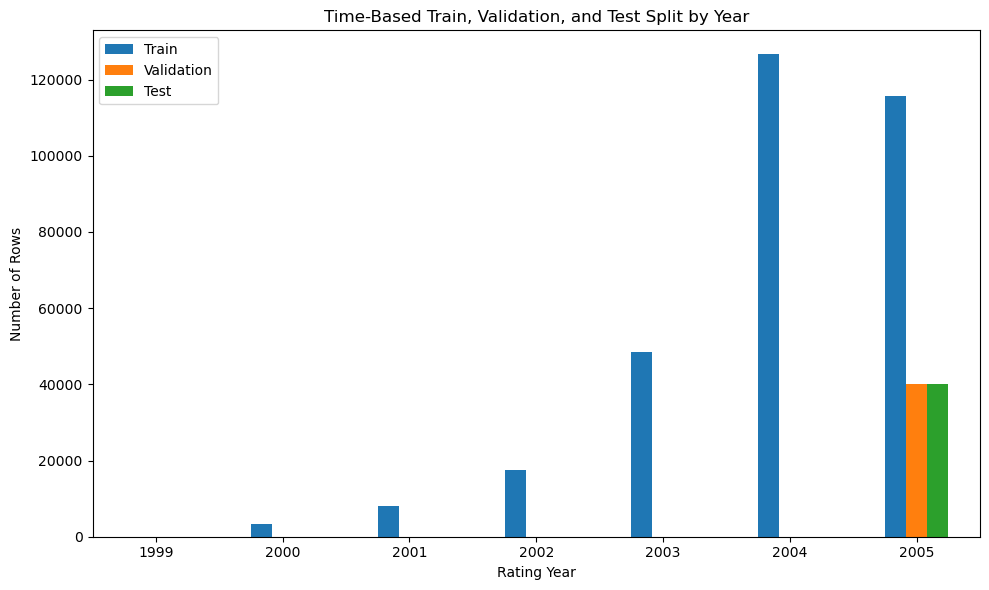

In [42]:
import pandas as pd
import matplotlib.pyplot as plt


train_years = train_df["year"].value_counts().sort_index()
val_years = val_df["year"].value_counts().sort_index()
test_years = test_df["year"].value_counts().sort_index()

split_years = pd.DataFrame({
    "Train": train_years,
    "Validation": val_years,
    "Test": test_years
}).fillna(0)

split_years.plot(kind="bar", figsize=(10, 6))
plt.xlabel("Rating Year")
plt.ylabel("Number of Rows")
plt.title("Time-Based Train, Validation, and Test Split by Year")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [43]:
train_df.to_csv("training/train.csv", index=False)
val_df.to_csv("training/validation.csv", index=False)
test_df.to_csv("training/test.csv", index=False)

print("Saved train.csv, validation.csv, and test.csv")

Saved train.csv, validation.csv, and test.csv
